# TT-23 — K-Means: Gom nhom san pham de sap xep lai ke hang

**Bai toan:** cua hang co ~4.000 ma hang. Muon sap xep lai ke theo **HANH VI MUA**
(ban nhanh/cham, mua le/mua si, nhieu khach/it khach quay lai...), khong theo danh muc
nha cung cap. Khong co nhan "dung/sai" nao ca → day la bai **hoc KHONG giam sat**: de
K-Means tu tim cac nhom san pham giong nhau.

**San pham ban giao:** `outputs/san_pham_theo_cum.csv` — moi ma hang thuoc 1 nhom, kem
ten nhom tieng Viet + de xuat vi tri trung bay cho bo phan trung bay.

**Don vi phan tich: SAN PHAM (`StockCode`)**, khong phai khach hang (khac bai RFM).

**Luong cua notebook:**

| Buoc | Noi dung | Ket qua |
|---|---|---|
| 0 | Tinh tay K-Means tren 6 diem | hieu thuat toan |
| 1 | Lam sach giao dich (4 buoc) | bang so dong loai |
| 2 | Tong hop len cap san pham, 8 dac trung | bang `sp` |
| 3 | Histogram truoc/sau `log1p` | `truoc_sau_log.png` |
| 4 | Tuong quan & PCA khu trung lap | chon bieu dien |
| 5 | Elbow + Silhouette K = 2..12 | `elbow_silhouette.png`, chon K |
| 6 | Thi nghiem `n_init` | `n_init_experiment.csv/png` |
| 7 | Mo hinh cuoi + scatter PCA | `pca_scatter.png` |
| 8–9 | Mo ta cum, dat ten, de xuat trung bay | `mo_ta_cum.png` |
| 10 | So sanh DBSCAN | `dbscan.png` |
| 11 | Xuat file ban giao | `san_pham_theo_cum.csv` |
| 12 | Kiem tra 3 gia dinh cua K-Means | |
| 13 | Mo rong: MiniBatch, Hierarchical, mua chung | |

## 0. K-Means hoat dong the nao — vi du tinh tay

Truoc khi dung sklearn, tu chay 1 vong K-Means bang numpy tren 6 diem 2 chieu, K = 2:

1. **Khoi tao:** lay 2 diem dau lam tam
2. **Gan:** moi diem ve tam GAN NHAT (khoang cach Euclid)
3. **Cap nhat:** doi tam ve TRUNG BINH cac diem vua gan
4. Lap 2–3 toi khi tam khong doi. Muc tieu giam dan: **inertia** = $\sum_i \lVert x_i - \mu_{c(i)} \rVert^2$

In [1]:
%matplotlib inline
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.stats import skew
from sklearn.cluster import DBSCAN, KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE_DIR / "src"))
from features import FEATURES, build_product_features, clean, load_raw, weekend_share
from cluster import (CLUSTER_CATALOG, K, assign_names, build_pipeline, build_preprocessor,
                     fit_and_export, profile_clusters)

REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

**Giai thich code:** nap thu vien va import ham tu `src/features.py` (doc + lam sach + tong hop)
va `src/cluster.py` (pipeline, mo ta cum, dat ten, xuat file). Notebook va script dung CHUNG
cac ham nay → chay notebook hay chay `python src/cluster.py` deu ra cung mot ket qua.

In [2]:
pts = np.array([[1.0, 1.0], [1.5, 2.0], [1.2, 0.8],    # nhom duoi-trai
                [5.0, 5.0], [5.5, 4.5], [4.8, 5.6]])   # nhom tren-phai
centers = pts[[0, 1]].copy()          # khoi tao XAU co y: 2 tam cung nam o nhom trai
for it in range(1, 4):
    d = np.linalg.norm(pts[:, None, :] - centers[None, :, :], axis=2)   # (6 diem x 2 tam)
    lab = d.argmin(axis=1)                                               # buoc GAN
    inertia = ((pts - centers[lab]) ** 2).sum()
    print(f"Vong {it}: nhan = {lab}, inertia (truoc khi doi tam) = {inertia:.2f}")
    new_centers = np.array([pts[lab == k].mean(axis=0) for k in range(2)])  # buoc CAP NHAT
    print("         tam moi =", new_centers.round(2).tolist())
    if np.allclose(new_centers, centers):
        print("  → tam khong doi, DUNG.")
        break
    centers = new_centers

km_demo = KMeans(n_clusters=2, n_init=10, random_state=0).fit(pts)
print("\nsklearn:", km_demo.labels_, "inertia =", round(km_demo.inertia_, 2))

Vong 1: nhan = [0 1 0 1 1 1], inertia (truoc khi doi tam) = 67.43
         tam moi = [[1.1, 0.9], [4.2, 4.28]]
Vong 2: nhan = [0 0 0 1 1 1], inertia (truoc khi doi tam) = 6.43
         tam moi = [[1.23, 1.27], [5.1, 5.03]]
Vong 3: nhan = [0 0 0 1 1 1], inertia (truoc khi doi tam) = 1.82
         tam moi = [[1.23, 1.27], [5.1, 5.03]]
  → tam khong doi, DUNG.



sklearn: [1 1 1 0 0 0] inertia = 1.82


**Giai thich:** du 2 tam ban dau cung nam o nhom trai, chi sau vai vong cap nhat, 1 tam da
"bi keo" sang nhom phai va inertia giam manh. sklearn cho cung cach chia (co the dao so thu tu
nhan 0/1 — **so hieu cum khong mang y nghia**, day la ly do phai DAT TEN cum o buoc 9).
Voi du lieu that nhieu chieu, khoi tao xau co the khien thuat toan ket o **cuc tieu dia phuong**
→ buoc 6 se kiem chung.

## 1. Doc va lam sach giao dich

Bo **Online Retail II (UCI)**: giao dich cua 1 cong ty ban le online (qua tang, do trang tri)
tai Anh, 12/2009 – 12/2011, gom 2 sheet. Lan doc dau tu file xlsx mat ~4 phut nen
`load_raw()` cache sang `data/online_retail_ii.parquet`.

In [3]:
raw = load_raw()
print(raw.shape)
print(raw.dtypes)
raw.head()

(1067371, 8)
Invoice                   str
StockCode                 str
Description            string
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom


In [4]:
tx, clean_log = clean(raw)
clean_log

,buoc,so_dong_con_lai,so_dong_bi_loai
0,Ban dau,1067371,0
1,1. Loai hoa don huy (Invoice bat dau 'C'),1047877,19494
2,2. Loai Quantity <= 0 va Price <= 0,1041670,6207
3,3. Loai StockCode khong phai san pham,1037037,4633
4,Loai dong trung lap hoan toan,1003373,33664


**Giai thich code:** `clean()` lam lan luot 4 buoc va ghi so dong bi loai o moi buoc:

1. **Hoa don huy** (`Invoice` bat dau bang `C`) — la giao dich tra hang, khong phai hanh vi mua.
2. **Quantity ≤ 0 hoac Price ≤ 0** — dieu chinh kho, hang tang, ghi sai.
3. **Ma khong phai san pham** — `POST`, `M`, `BANK CHARGES`, `DOT`, `ADJUST`... Ngoai danh sach co
   dinh, ham coi moi ma **khong chua chu so** la ma phi (san pham that luon co phan so, vd `85123A`)
   → bat them `AMAZONFEE`, `DCGSSGIRL`, `GIFT`...
4. Them: loai dong **trung lap hoan toan** (cung hoa don, cung ma, cung so luong, cung gio) — loi ghi
   kep, neu giu lai se thoi phong so luong.

Buoc 4 cua de bai (san pham < 5 don) lam o cap san pham ngay ben duoi.

In [5]:
from features import is_non_product
step2 = raw[~raw["Invoice"].str.startswith("C") & (raw["Quantity"] > 0) & (raw["Price"] > 0)]
print("Ma bi loai o buoc 3 (so dong):")
print(step2.loc[is_non_product(step2["StockCode"]), "StockCode"].value_counts().to_string())

Ma bi loai o buoc 3 (so dong):
StockCode
POST            1886
DOT             1436
M                881
C2               272
ADJUST            36
BANK CHARGES      35
DCGSSGIRL         23
DCGSSBOY          21
PADS              17
TEST001            9
D                  5
AMAZONFEE          4
S                  3
ADJUST2            3
TEST002            1
B                  1


## 2. Tong hop len cap san pham — 8 dac trung

In [6]:
sp_all = build_product_features(tx, min_orders=1)
sp = build_product_features(tx)          # min_orders = 5
sp = sp.merge(weekend_share(tx), left_on="StockCode", right_index=True, how="left")
print(f"San pham sau lam sach : {len(sp_all):,}")
print(f"Loai vi < 5 don        : {len(sp_all) - len(sp):,}  "
      f"({(1 - sp['tong_doanh_thu'].sum() / sp_all['tong_doanh_thu'].sum()):.2%} doanh thu)")
print(f"Con lai de gom cum    : {len(sp):,}")
sp[["StockCode", "Description"] + FEATURES].head()

San pham sau lam sach : 4,729
Loai vi < 5 don        : 334  (0.98% doanh thu)
Con lai de gom cum    : 4,395


,StockCode,Description,tong_so_luong,tong_doanh_thu,gia_trung_binh,so_don_hang,so_khach_mua,do_lech_sl,sl_moi_don,ty_le_mua_lai
0,10002,INFLATABLE POLITICAL GLOBE,8671,"6,942.260",0.979,362,164,57.384,23.953,2.207
1,10080,GROOVY CACTUS INFLATABLE,315,129.290,0.505,27,23,10.987,11.667,1.174
2,10120,DOGGY RUBBER,664,142.740,0.240,73,52,11.884,9.096,1.404
3,10123C,HEARTS WRAPPING TAPE,650,254.410,0.791,63,39,27.471,10.317,1.615
4,10123G,ARMY CAMO WRAPPING TAPE,2251,165.560,0.821,16,12,365.707,140.688,1.333


**Giai thich code:** `groupby('StockCode')` gom ~1 trieu dong giao dich thanh 1 dong / san pham:

| Dac trung | Y nghia hanh vi |
|---|---|
| `tong_so_luong`, `tong_doanh_thu` | quy mo ban |
| `gia_trung_binh` | phan khuc gia |
| `so_don_hang`, `so_khach_mua` | do pho bien |
| `do_lech_sl` | so luong moi lan mua dao dong manh hay deu |
| `sl_moi_don` = SL / so don | mua le hay mua si |
| `ty_le_mua_lai` = so don / so khach | khach co quay lai mua tiep khong |

San pham < 5 don bi loai: qua it giao dich de mo ta "hanh vi" (do lech chuan cua 1–2 don vo nghia),
va chung chi chiem ty le doanh thu rat nho. `ty_le_dt_cuoi_tuan` (% doanh thu thu 6–CN) **khong**
dua vao K-Means, chi dung de MO TA cum sau nay (kiem chung gia thuyet "nhom mua dot bien cuoi tuan").

In [7]:
sp[FEATURES].describe(percentiles=[0.5, 0.9, 0.99]).T

,count,mean,std,min,50%,90%,99%,max
tong_so_luong,"4,395.000","2,522.434","5,965.992",5.000,776.000,"6,145.000","26,842.620","106,139.000"
tong_doanh_thu,"4,395.000","4,425.918","11,269.205",3.780,"1,311.480","10,588.844","48,340.316","330,590.320"
gia_trung_binh,"4,395.000",4.090,7.777,0.050,2.490,8.483,25.095,214.865
so_don_hang,"4,395.000",225.556,343.453,5.000,105.000,576.600,"1,704.080","5,464.000"
so_khach_mua,"4,395.000",109.317,136.598,0.000,59.000,279.600,626.000,"1,490.000"
do_lech_sl,"4,395.000",31.915,149.744,0.000,11.261,44.306,442.869,"4,692.895"
sl_moi_don,"4,395.000",12.388,47.396,1.000,6.505,19.988,104.590,"2,447.200"
ty_le_mua_lai,"4,395.000",2.168,1.957,1.000,1.738,3.127,9.628,48.000


## 3. Phan phoi lech — histogram truoc va sau `log1p`

Nhin bang tren: `tong_doanh_thu` trung vi vai nghin nhung max > 300.000; `sl_moi_don` p99 vai tram,
max > 2.400. Day la "san pham ca voi".

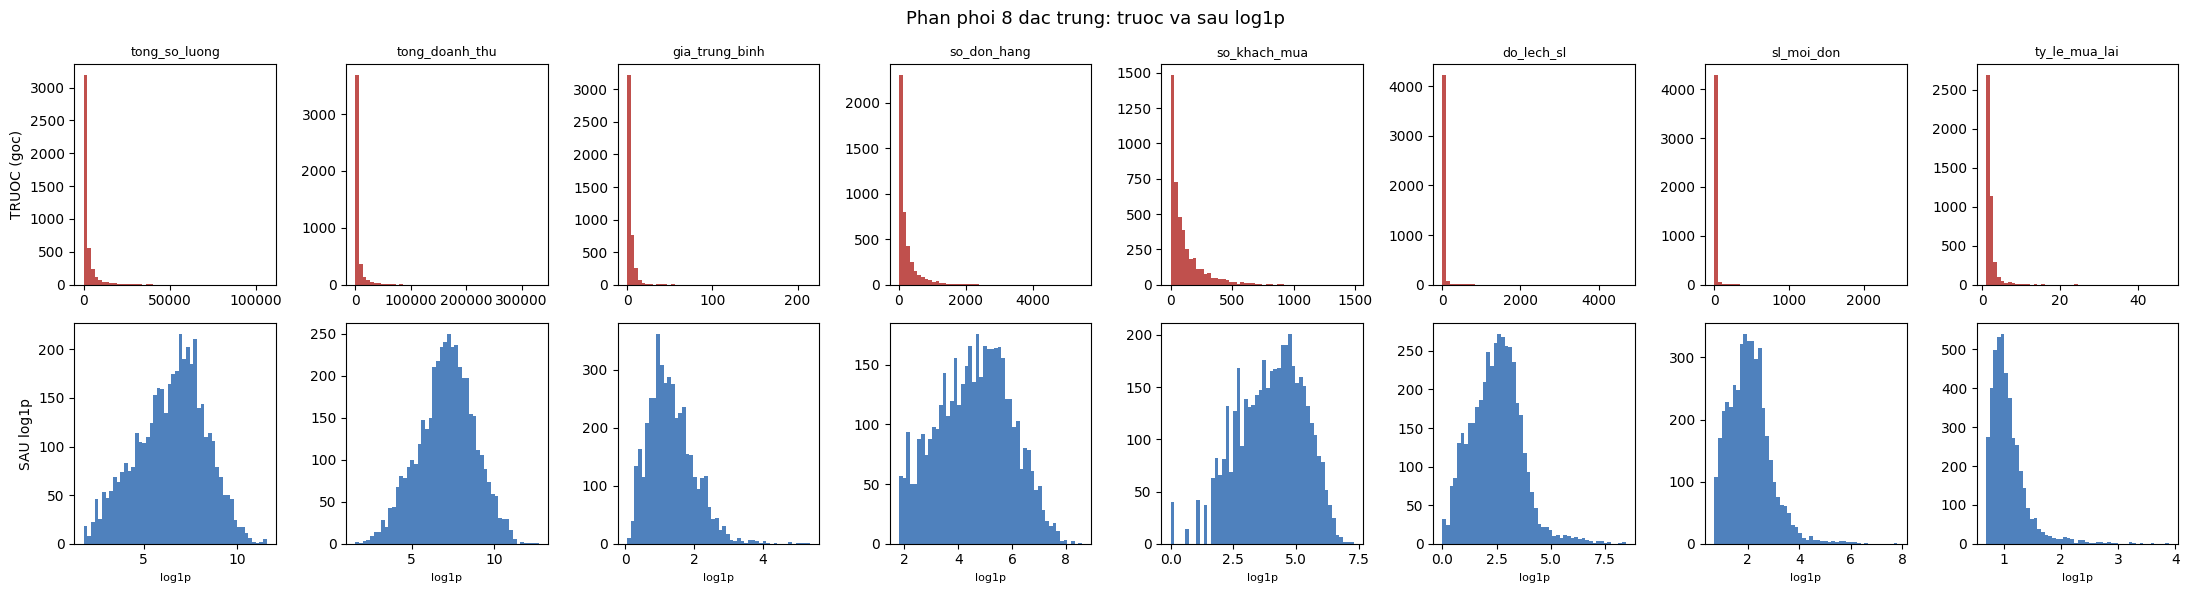

,skew_goc,skew_sau_log1p
dac_trung,,
tong_so_luong,7.908,-0.255
tong_doanh_thu,11.825,-0.169
gia_trung_binh,14.229,0.936
so_don_hang,4.084,-0.058
so_khach_mua,2.588,-0.341
do_lech_sl,18.272,0.568
sl_moi_don,33.993,1.067
ty_le_mua_lai,9.350,2.504


In [8]:
fig, axes = plt.subplots(2, 8, figsize=(22, 6))
skew_tbl = []
for j, f in enumerate(FEATURES):
    x = sp[f].values
    axes[0, j].hist(x, bins=50, color="#c0504d")
    axes[0, j].set_title(f, fontsize=9)
    axes[1, j].hist(np.log1p(x), bins=50, color="#4f81bd")
    axes[1, j].set_xlabel("log1p", fontsize=8)
    skew_tbl.append((f, skew(x), skew(np.log1p(x))))
axes[0, 0].set_ylabel("TRUOC (goc)")
axes[1, 0].set_ylabel("SAU log1p")
fig.suptitle("Phan phoi 8 dac trung: truoc va sau log1p", fontsize=13)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "truoc_sau_log.png", dpi=120)
plt.show()
skew_df = pd.DataFrame(skew_tbl, columns=["dac_trung", "skew_goc", "skew_sau_log1p"]).set_index("dac_trung")
skew_df

**Giai thich:** hang tren — phan lon san pham don cuc o cot dau, vai diem rat xa ben phai
(do lech `skew` 2,6–34). K-Means dung **khoang cach Euclid binh phuong** nen vai diem ca voi do se
chiem gan het inertia va keo tam cum ve phia chung. Sau `log1p` (hang duoi), phan phoi gan doi xung,
skew cua 7/8 dac trung giam ve khoang −0,3…1,1 (rieng `ty_le_mua_lai` con 2,5 vi gia tri ≥ 1 va
don sat 1 — van giam gan 4 lan so voi 9,4) → chung minh BAT BUOC phai bien doi log **truoc** khi chuan hoa.

Them vi du kiem chung: neu bo log, chay K-Means se ra 1 cum khong lo + vai cum chi vai san pham.

In [9]:
X_nolog = StandardScaler().fit_transform(sp[FEATURES])
lab_nolog = KMeans(K, n_init=10, random_state=RANDOM_STATE).fit_predict(X_nolog)
print("KHONG log1p  - kich thuoc 5 cum:", sorted(np.bincount(lab_nolog), reverse=True))
X_log = StandardScaler().fit_transform(np.log1p(sp[FEATURES]))
lab_log = KMeans(K, n_init=10, random_state=RANDOM_STATE).fit_predict(X_log)
print("CO log1p     - kich thuoc 5 cum:", sorted(np.bincount(lab_log), reverse=True))

KHONG log1p  - kich thuoc 5 cum: [np.int64(3537), np.int64(726), np.int64(109), np.int64(15), np.int64(8)]
CO log1p     - kich thuoc 5 cum: [np.int64(1192), np.int64(1163), np.int64(923), np.int64(870), np.int64(247)]


**Giai thich:** khong log → hau het san pham don vao 1 cum, cac cum con lai chi la vai "ca voi"
— vo dung cho trung bay. Co log → cac cum co kich thuoc hop ly.

## 4. Dac trung trung lap → them buoc PCA

Sau log + chuan hoa, 8 dac trung co dang ngang nhau ve **thang do**, nhung co ngang nhau ve **thong tin**?

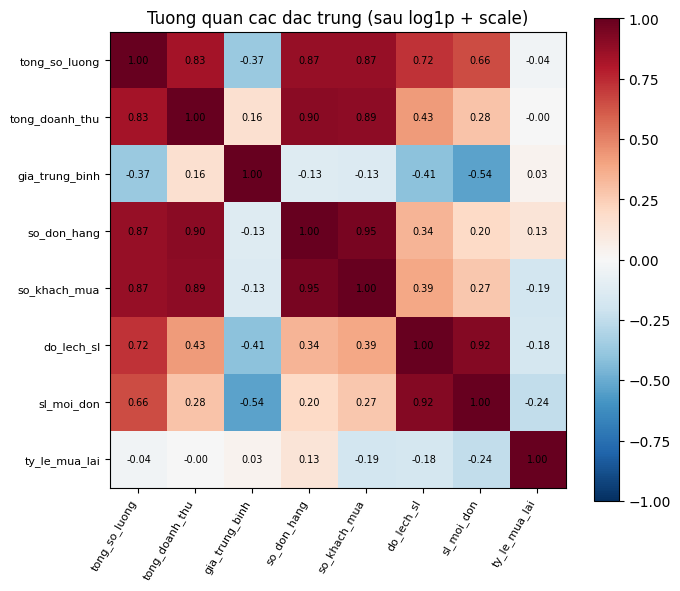

In [10]:
corr = pd.DataFrame(X_log, columns=FEATURES).corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(8), FEATURES, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(8), FEATURES, fontsize=8)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
ax.set_title("Tuong quan cac dac trung (sau log1p + scale)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "tuong_quan.png", dpi=120)
plt.show()

**Giai thich:** `tong_so_luong`, `tong_doanh_thu`, `so_don_hang`, `so_khach_mua` tuong quan 0,83–0,90 —
ca 4 deu do cung 1 thu la **"ban nhieu hay it"**; `do_lech_sl` va `sl_moi_don` tuong quan 0,92.
Voi khoang cach Euclid, chieu "quy mo" bi tinh **4 lan** → vi pham ngam gia dinh ② (moi dac trung
quan trong ngang nhau).

Giai phap: them **PCA** sau scale, giu cac thanh phan giai thich ≥ 90% phuong sai. PCA xoay truc ve
cac huong khong tuong quan va bo cac huong chi chua nhieu — van dung CA 8 dac trung (khong phai tu tay
chon bot).

In [11]:
pre = build_preprocessor().fit(sp[FEATURES])
pca = pre["pca"]
print("So thanh phan giu lai:", pca.n_components_,
      "| phuong sai giu lai:", round(pca.explained_variance_ratio_.sum(), 3))
from sklearn.decomposition import PCA
evr = PCA().fit(X_log).explained_variance_ratio_
print("Ty le phuong sai tung PC (day du 8 PC):", evr.round(3))
pd.DataFrame(pca.components_, columns=FEATURES,
             index=[f"PC{i + 1}" for i in range(pca.n_components_)]).round(2)

So thanh phan giu lai: 3 | phuong sai giu lai: 0.906
Ty le phuong sai tung PC (day du 8 PC): [0.544 0.234 0.129 0.083 0.009 0.002 0.    0.   ]


,tong_so_luong,tong_doanh_thu,gia_trung_binh,so_don_hang,so_khach_mua,do_lech_sl,sl_moi_don,ty_le_mua_lai
PC1,0.480,0.410,-0.160,0.410,0.430,0.360,0.310,-0.060
PC2,0.000,-0.340,-0.480,-0.340,-0.260,0.390,0.510,-0.230
PC3,0.090,-0.100,-0.370,0.130,-0.150,0.000,-0.000,0.900


**Giai thich (doc ma tran tai trong):**
- **PC1** (54%) — tai duong deu len so luong, doanh thu, so don, so khach → truc **"quy mo ban"**.
- **PC2** (23%) — `sl_moi_don`, `do_lech_sl` duong; `gia_trung_binh`, so don am → truc **"mua si gia re ↔ mua le gia cao"**.
- **PC3** (13%) — gan nhu chi `ty_le_mua_lai` → truc **"khach quay lai"**.

3 truc nay chinh la 3 cau hoi kinh doanh cua bo phan trung bay. 5 PC con lai chi ~9% phuong sai.

So sanh silhouette giua 2 cach bieu dien o buoc tiep theo.

## 5. Chon K: Elbow + Silhouette (K = 2..12)

In [12]:
Z = pre.transform(sp[FEATURES])
rows = []
for k in range(2, 13):
    km_full = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(X_log)
    km_pca = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    rows.append({"K": k,
                 "inertia_8D": km_full.inertia_, "silhouette_8D": silhouette_score(X_log, km_full.labels_),
                 "inertia_PCA": km_pca.inertia_, "silhouette_PCA": silhouette_score(Z, km_pca.labels_),
                 "cum_nho_nhat_PCA": np.bincount(km_pca.labels_).min()})
k_tbl = pd.DataFrame(rows).set_index("K")
k_tbl.to_csv(REPORTS_DIR / "chon_K.csv")
k_tbl

,inertia_8D,silhouette_8D,inertia_PCA,silhouette_PCA,cum_nho_nhat_PCA
K,,,,,
2,"22,292.745",0.337,"19,007.603",0.367,1758
3,"18,439.268",0.258,"15,213.170",0.282,1302
4,"15,737.598",0.241,"12,544.349",0.278,944
5,"13,609.632",0.248,"10,509.701",0.287,258
6,"12,157.612",0.247,"9,300.038",0.276,246
7,"11,013.210",0.235,"8,212.570",0.276,234
8,"10,154.617",0.230,"7,450.862",0.275,224
9,"9,448.115",0.236,"6,878.795",0.274,197
10,"8,977.022",0.230,"6,426.672",0.262,143


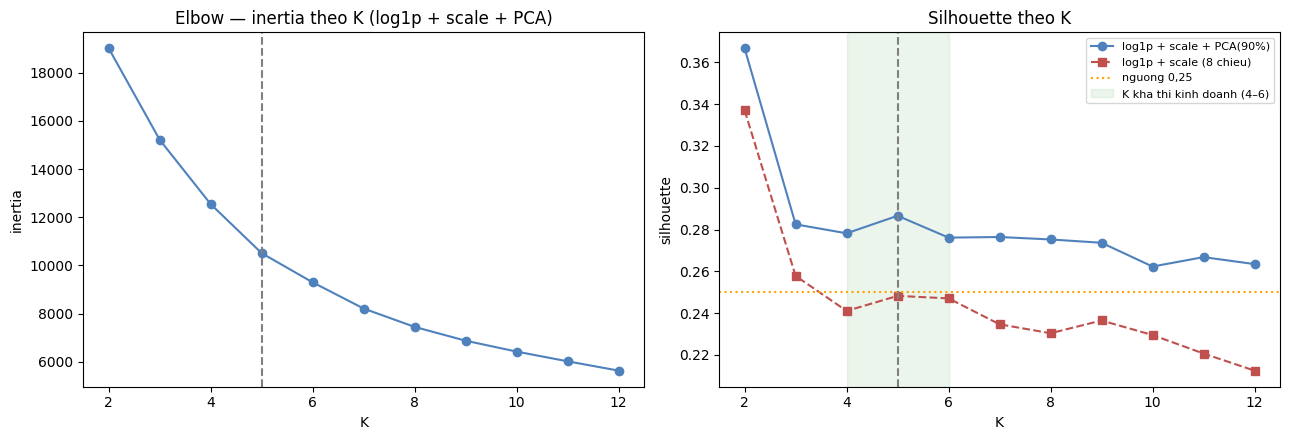

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(k_tbl.index, k_tbl["inertia_PCA"], "o-", color="#4f81bd")
a1.axvline(K, color="gray", ls="--")
a1.set(title="Elbow — inertia theo K (log1p + scale + PCA)", xlabel="K", ylabel="inertia")
a2.plot(k_tbl.index, k_tbl["silhouette_PCA"], "o-", color="#4f81bd", label="log1p + scale + PCA(90%)")
a2.plot(k_tbl.index, k_tbl["silhouette_8D"], "s--", color="#c0504d", label="log1p + scale (8 chieu)")
a2.axhline(0.25, color="orange", ls=":", label="nguong 0,25")
a2.axvspan(4, 6, color="green", alpha=0.08, label="K kha thi kinh doanh (4–6)")
a2.axvline(K, color="gray", ls="--")
a2.set(title="Silhouette theo K", xlabel="K", ylabel="silhouette")
a2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "elbow_silhouette.png", dpi=120)
plt.show()

**Giai thich & quyet dinh K:**

- **Elbow:** duong inertia cong deu, "khuyu tay" mo ho quanh K = 3–5 — dung nhu de bai canh bao.
- **Silhouette:** cao nhat o K = 2, nhung 2 nhom ("ban chay" / "ban cham") qua tho, khong giup sap
  ke. Trong vung **K = 4–6** (gioi han kinh doanh), **K = 5** cho silhouette cao nhat cua bieu dien PCA.
- **Bieu dien PCA** cho silhouette cao hon bieu dien 8 chieu o moi K (bo bot nhieu + bo trung lap).
  Bieu dien 8 chieu o K = 4–6 chi ~0,24–0,25, sat nguong "cum chong lan".
- **Kinh doanh:** 5 nhom = 5 khu trung bay, bo phan trung bay quan ly duoc; tu K = 6 silhouette khong
  tang nua, them cum chi chia nho cac cum cu (cum nho nhat giam tu ~250 xuong ~110 ma o K = 11–12).

→ **Chon K = 5** (can cu kep: silhouette tot nhat trong vung 4–6 + so khu trung bay kha thi).

## 6. Thi nghiem `n_init` — K-Means phu thuoc khoi tao

Chay K = 5 voi `n_init = 1` va 10 seed khac nhau, so sanh voi `n_init = 10`. Do giong nhau giua cac
lan chay bang **ARI** (Adjusted Rand Index: 1 = chia giong het, khong quan tam so hieu cum; ~0 = ngau nhien).

In [14]:
ref = KMeans(K, n_init=50, random_state=RANDOM_STATE).fit(Z)   # nghiem tot nhat tim duoc lam moc
rows = []
for init in ["random", "k-means++"]:
    for n_init in [1, 10]:
        for seed in range(10):
            km = KMeans(K, init=init, n_init=n_init, random_state=seed).fit(Z)
            rows.append({"init": init, "n_init": n_init, "seed": seed, "inertia": km.inertia_,
                         "ARI_vs_tot_nhat": adjusted_rand_score(ref.labels_, km.labels_),
                         "kich_thuoc_cum": sorted(np.bincount(km.labels_).tolist())})
ninit = pd.DataFrame(rows)
ninit.to_csv(REPORTS_DIR / "n_init_experiment.csv", index=False)
summary = ninit.groupby(["init", "n_init"]).agg(
    inertia_min=("inertia", "min"), inertia_max=("inertia", "max"),
    ARI_min=("ARI_vs_tot_nhat", "min"), ARI_tb=("ARI_vs_tot_nhat", "mean"),
    so_lan_lech=("ARI_vs_tot_nhat", lambda s: int((s < 0.95).sum())))
summary

inertia_min  inertia_max  ARI_min  ARI_tb  so_lan_lech
init      n_init                                                        
k-means++ 1        10,509.691   11,171.860    0.369   0.813            5
          10       10,509.689   10,509.761    0.995   0.997            0
random    1        10,509.751   11,387.845    0.491   0.715            7
          10       10,509.684   10,509.714    0.995   0.996            0

In [15]:
ninit[(ninit["init"] == "random") & (ninit["n_init"] == 1)][["seed", "inertia", "ARI_vs_tot_nhat", "kich_thuoc_cum"]]

,seed,inertia,ARI_vs_tot_nhat,kich_thuoc_cum
0,0,"10,509.751",0.998,"[257, 899, 974, 1064, 1201]"
1,1,"11,387.845",0.497,"[498, 705, 919, 1053, 1220]"
2,2,"11,008.095",0.599,"[587, 729, 924, 1028, 1127]"
3,3,"11,009.956",0.575,"[604, 714, 945, 1015, 1117]"
4,4,"10,518.488",0.863,"[254, 828, 982, 1153, 1178]"
5,5,"10,509.782",0.996,"[257, 900, 972, 1062, 1204]"
6,6,"11,008.339",0.598,"[594, 724, 924, 1029, 1124]"
7,7,"10,511.035",0.960,"[257, 880, 968, 1093, 1197]"
8,8,"11,009.944",0.577,"[604, 717, 941, 1012, 1121]"
9,9,"11,387.247",0.491,"[502, 713, 909, 1046, 1225]"


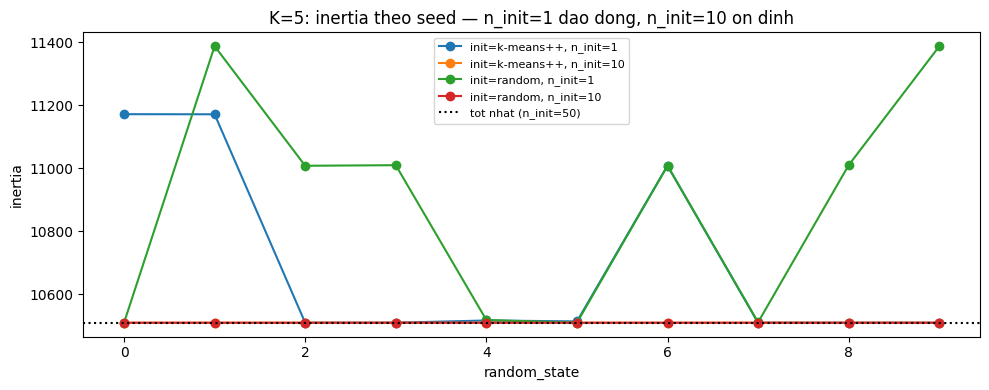

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for (init, n_init), g in ninit.groupby(["init", "n_init"]):
    ax.plot(g["seed"], g["inertia"], "o-", label=f"init={init}, n_init={n_init}")
ax.axhline(ref.inertia_, color="black", ls=":", label="tot nhat (n_init=50)")
ax.set(xlabel="random_state", ylabel="inertia", title="K=5: inertia theo seed — n_init=1 dao dong, n_init=10 on dinh")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "n_init_experiment.png", dpi=120)
plt.show()

**Giai thich:** voi `n_init = 1`, mot so seed ket o **cuc tieu dia phuong**: inertia cao hon ro va cach
chia khac han (ARI thap, kich thuoc cum khac) — tuc la **cung du lieu, chay lai ra danh sach san pham
khac nhau** → bo phan trung bay khong the tin. `k-means++` (mac dinh sklearn) rai tam ban dau xa nhau nen
do hon `random` mot chut (5/10 seed lech so voi 7/10) nhung van khong mien nhiem — seed xau nhat
con ARI 0,37.

`n_init = 10` chay 10 lan khoi tao va giu lan co inertia thap nhat → moi seed deu hoi tu ve cung nghiem
(ARI ≈ 1). Chi phi chi la x10 thoi gian tren 4.400 diem — vai giay.

## 7. Mo hinh cuoi + scatter PCA

Pipeline chinh thuc (`src/cluster.py::build_pipeline`):
`log1p → StandardScaler → PCA(90%) → KMeans(K=5, n_init=10, random_state=42)`.

In [17]:
pipe = build_pipeline(K).fit(sp[FEATURES])
sp["cum"] = pipe["km"].labels_
Z = pipe[:-1].transform(sp[FEATURES])
sil_final = silhouette_score(Z, sp["cum"])
print(f"K = {K} | inertia = {pipe['km'].inertia_:,.1f} | silhouette = {sil_final:.3f}")

prof = profile_clusters(sp)
keys = assign_names(prof)
ten = {c: CLUSTER_CATALOG[keys[c]][0] for c in prof.index}
sp["ten_cum"] = sp["cum"].map(ten)
print(sp["ten_cum"].value_counts().to_string())

K = 5 | inertia = 10,509.7 | silhouette = 0.287
ten_cum
Hàng giá khá bán đều      1206
Hàng chủ lực bán chạy     1062
Hàng mua sỉ theo lô        970
Hàng đuôi dài bán chậm     899
Hàng ngách khách quen      258


In [18]:
from sklearn.metrics import silhouette_samples
sp["silhouette"] = silhouette_samples(Z, sp["cum"])
sp.groupby("ten_cum")["silhouette"].agg(["mean", "median", lambda s: (s < 0).mean()]).rename(
    columns={"<lambda_0>": "ty_le_am"})

,mean,median,ty_le_am
ten_cum,,,
Hàng chủ lực bán chạy,0.324,0.353,0.000
Hàng giá khá bán đều,0.276,0.284,0.003
Hàng mua sỉ theo lô,0.253,0.260,0.032
Hàng ngách khách quen,0.281,0.298,0.066
Hàng đuôi dài bán chậm,0.293,0.318,0.036


**Giai thich:** silhouette tung san pham. *Chu luc* tach ro nhat (TB 0,32, khong co gia tri am).
*Mua si theo lo* co TB thap nhat (0,25) — nam giua *chu luc* va *ban deu* tren truc PC2. *Khach quen*
co 6,6% san pham silhouette am: cum nho, trai rong, nhieu ma nam lung chung voi *duoi dai ban cham*.

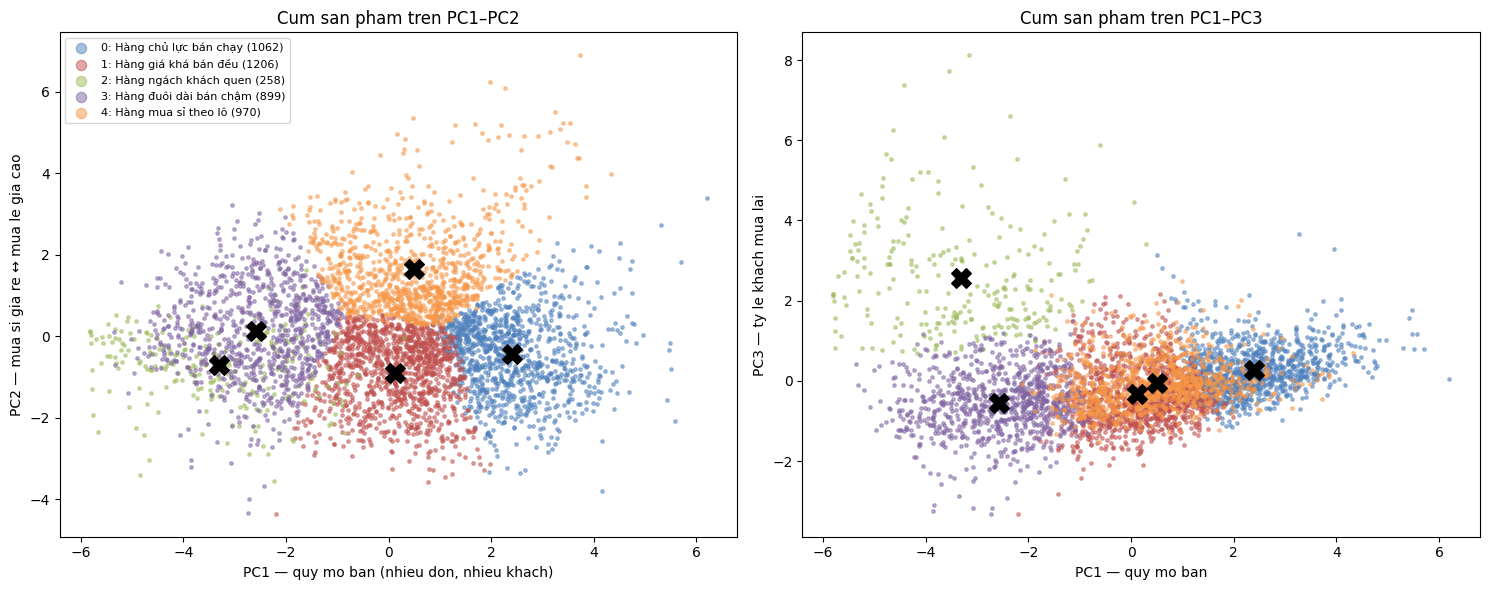

In [19]:
colors = ["#4f81bd", "#c0504d", "#9bbb59", "#8064a2", "#f79646"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
for c in sorted(sp["cum"].unique()):
    m = sp["cum"].values == c
    a1.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.5, color=colors[c], label=f"{c}: {ten[c]} ({m.sum()})")
    a2.scatter(Z[m, 0], Z[m, 2], s=6, alpha=0.5, color=colors[c])
cent = pipe["km"].cluster_centers_
for a, j in [(a1, 1), (a2, 2)]:
    a.scatter(cent[:, 0], cent[:, j], marker="X", s=200, c="black")
a1.set(xlabel="PC1 — quy mo ban (nhieu don, nhieu khach)", ylabel="PC2 — mua si gia re ↔ mua le gia cao",
       title="Cum san pham tren PC1–PC2")
a2.set(xlabel="PC1 — quy mo ban", ylabel="PC3 — ty le khach mua lai", title="Cum san pham tren PC1–PC3")
a1.legend(markerscale=3, fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "pca_scatter.png", dpi=120)
plt.show()

**Giai thich:** mo hinh gom cum tren 3 PC; ve 2 mat cat PC1–PC2 va PC1–PC3 (X den = tam cum).
- Truc PC1 tach **chu luc** (phai) ↔ **duoi dai ban cham** (trai).
- PC2 tach **mua si theo lo** (tren) ↔ **gia kha ban deu** (duoi).
- Cum **khach quen** chi tach ro tren PC3 — vi vay can giu 3 PC, khong chi 2.
Cac cum tiep giap nhau (khong co khoang trong ro) → silhouette ~0,29 la "chap nhan duoc", dung voi
du lieu hanh vi lien tuc.

## 8. Bang mo ta cum

In [20]:
prof["ten_cum"] = prof.index.map(ten)
show = prof[["ten_cum", "so_ma_hang", "pct_ma_hang", "pct_doanh_thu", "gia_tb_median", "so_don_median",
             "so_khach_median", "sl_moi_don_median", "ty_le_mua_lai_median", "dt_cuoi_tuan_median"]]
show

,ten_cum,so_ma_hang,pct_ma_hang,pct_doanh_thu,gia_tb_median,so_don_median,so_khach_median,sl_moi_don_median,ty_le_mua_lai_median,dt_cuoi_tuan_median
cum,,,,,,,,,,
0,Hàng chủ lực bán chạy,1062,24.164,71.945,1.799,468.500,242.000,10.041,2.023,0.245
1,Hàng giá khá bán đều,1206,27.440,21.112,3.990,151.000,83.000,4.656,1.722,0.243
2,Hàng ngách khách quen,258,5.870,0.415,2.952,28.500,5.000,1.628,5.477,0.205
3,Hàng đuôi dài bán chậm,899,20.455,1.676,3.773,21.000,13.000,2.875,1.424,0.245
4,Hàng mua sỉ theo lô,970,22.071,4.852,1.276,66.000,40.000,14.614,1.494,0.223


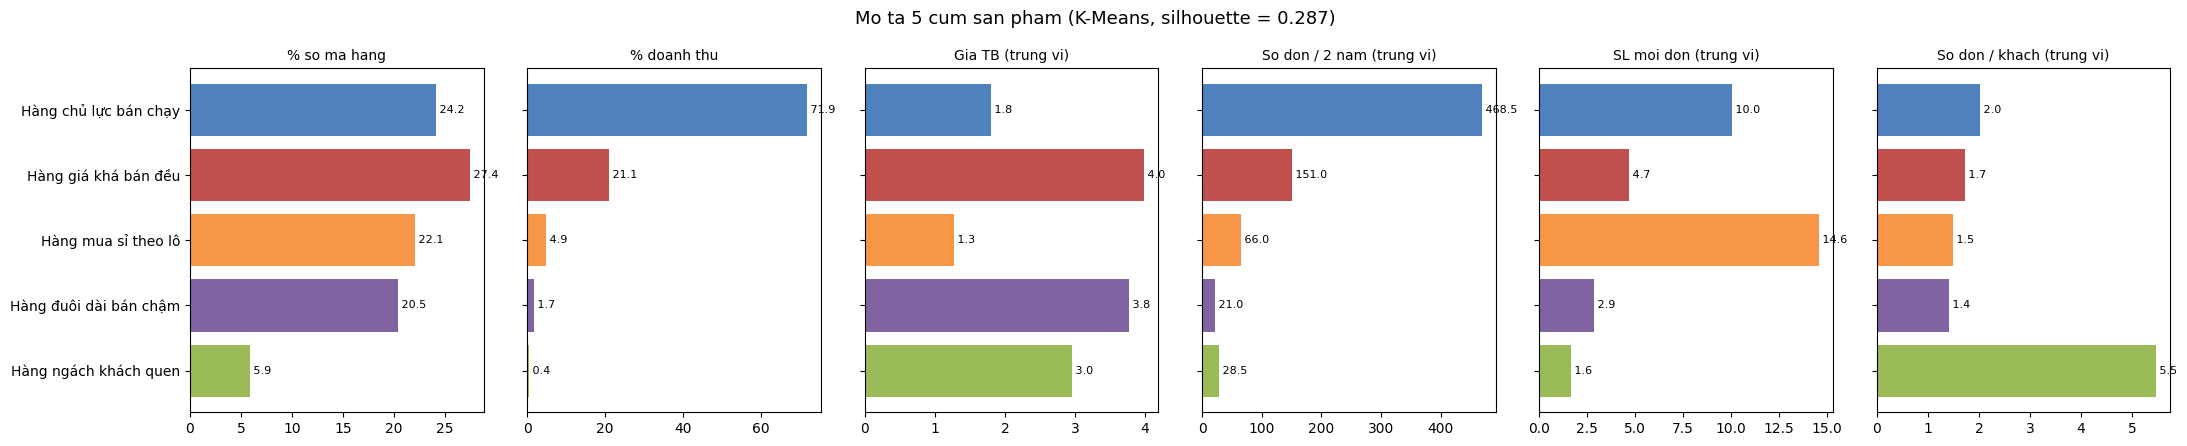

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4.5))
cols = [("pct_ma_hang", "% so ma hang"), ("pct_doanh_thu", "% doanh thu"), ("gia_tb_median", "Gia TB (trung vi)"),
        ("so_don_median", "So don / 2 nam (trung vi)"), ("sl_moi_don_median", "SL moi don (trung vi)"),
        ("ty_le_mua_lai_median", "So don / khach (trung vi)")]
order = prof.sort_values("pct_doanh_thu").index
for ax, (col, title) in zip(axes, cols):
    ax.barh([ten[c] for c in order], prof.loc[order, col], color=[colors[c] for c in order])
    ax.set_title(title, fontsize=10)
    for y, v in enumerate(prof.loc[order, col]):
        ax.text(v, y, f" {v:,.1f}", va="center", fontsize=8)
    if ax is not axes[0]:
        ax.set_yticklabels([])
fig.suptitle(f"Mo ta 5 cum san pham (K-Means, silhouette = {sil_final:.3f})", fontsize=13)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "mo_ta_cum.png", dpi=120)
plt.show()

In [22]:
for c in prof.sort_values("pct_doanh_thu", ascending=False).index:
    top = sp[sp["cum"] == c].nlargest(6, "tong_doanh_thu")["Description"].str.strip().tolist()
    print(f"[{c}] {ten[c]}:\n    " + " | ".join(top))

[0] Hàng chủ lực bán chạy:
    REGENCY CAKESTAND 3 TIER | WHITE HANGING HEART T-LIGHT HOLDER | JUMBO BAG RED RETROSPOT | PARTY BUNTING | ASSORTED COLOUR BIRD ORNAMENT | PAPER CHAIN KIT 50'S CHRISTMAS
[1] Hàng giá khá bán đều:
    SET/4 WHITE RETRO STORAGE CUBES | CREAM SWEETHEART MINI CHEST | PICNIC BASKET WICKER LARGE | RED RETROSPOT ROUND CAKE TINS | IVORY KITCHEN SCALES | TEA TIME CAKE STAND IN GIFT BOX
[4] Hàng mua sỉ theo lô:
    SMALL CHINESE STYLE SCISSOR | AFGHAN SLIPPER SOCK PAIR | SMALL FAIRY CAKE FRIDGE MAGNETS | PINK/BROWN DOTS RUFFLED UMBRELLA | LARGE ZINC HEART WALL ORGANISER | PANTRY CHOPPING BOARD
[3] Hàng đuôi dài bán chậm:
    VINTAGE BLUE KITCHEN CABINET | RUSTIC  SEVENTEEN DRAWER SIDEBOARD | LOVE SEAT ANTIQUE WHITE METAL | HALL CABINET WITH 3 DRAWERS | FUSCHIA RETRO BAR STOOL | CHEST NATURAL WOOD 20 DRAWERS
[2] Hàng ngách khách quen:
    RED RETRO BAR STOOL | TEATIME FUNKY FLOWER BACKPACK FOR 2 | PINK HAWAIIAN PICNIC HAMPER FOR 2 | SOFT PINK ROSE TOWEL | FLOOR CUSHI

**Giai thich:** dung **trung vi** thay vi trung binh de mo ta cum — trung binh van bi vai ca voi keo
lech (vd 1 san pham doanh thu 330.000). Doc bang + vi du san pham:

| Cum | Dau hieu nhan dien |
|---|---|
| **Hang chu luc ban chay** | ~1/4 so ma nhung ~72% doanh thu; ~470 don, ~240 khach; gia re (~1,8) |
| **Hang gia kha ban deu** | ~1/5 doanh thu; gia cao hon (~4); ~150 don; mua 4–5 cai/don |
| **Hang mua si theo lo** | gia thap nhat (~1,3) nhung ~15 cai/don, do lech SL lon (don to don nho) |
| **Hang duoi dai ban cham** | ~1/5 so ma nhung < 2% doanh thu; ~21 don/2 nam; gom ca noi that dat tien |
| **Hang ngach khach quen** | cum nho nhat; chi ~5 khach nhung moi khach mua lai ~5,5 lan |

**Gia thuyet "mua dot bien cuoi tuan":** cot `dt_cuoi_tuan_median` (% doanh thu thu 6 – CN) gan
nhu bang nhau o moi cum (~20–25%) → **KHONG tim thay** nhom san pham cuoi tuan. Nguyen nhan du lieu:
day la nha ban si online, gan nhu **khong co giao dich thu 7** (xem bang duoi) — hanh vi theo ngay
trong tuan khong phai yeu to phan biet san pham o bo du lieu nay.

In [23]:
thu = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
dow = tx["InvoiceDate"].dt.dayofweek.value_counts().sort_index()
pd.DataFrame({"thu": [thu[i] for i in dow.index], "so_dong": dow.values,
              "ty_le": (dow / dow.sum()).values}).set_index("thu").T

thu,T2,T3,T4,T5,T6,T7,CN
so_dong,"178,734.000","185,488.000","172,295.000","189,620.000","145,200.000",400.000,"131,636.000"
ty_le,0.178,0.185,0.172,0.189,0.145,0.000,0.131


## 9. Dat ten cum + de xuat trung bay

Ten cum KHONG gan cung theo so hieu (0..4 do K-Means dat ngau nhien), ma theo **luat tren ho so trung vi**
(`assign_names`): nhieu don nhat → *chu luc*; ty le mua lai cao nhat → *khach quen*; SL/don cao nhat →
*mua si*; it don nhat trong so con lai → *duoi dai*; cum con lai → *gia kha ban deu*. Doi seed hay chay
lai tren du lieu moi, ten van gan dung cum.

In [24]:
names_tbl = pd.DataFrame({
    "ten_cum": [CLUSTER_CATALOG[keys[c]][0] for c in prof.index],
    "so_ma_hang": prof["so_ma_hang"].values,
    "pct_doanh_thu": prof["pct_doanh_thu"].round(1).values,
    "mo_ta": [CLUSTER_CATALOG[keys[c]][1] for c in prof.index],
    "de_xuat_trung_bay": [CLUSTER_CATALOG[keys[c]][2] for c in prof.index],
}, index=prof.index).sort_values("pct_doanh_thu", ascending=False)
with pd.option_context("display.max_colwidth", 120):
    display(names_tbl)

,ten_cum,so_ma_hang,pct_doanh_thu,mo_ta,de_xuat_trung_bay
cum,,,,,
0,Hàng chủ lực bán chạy,1062,71.900,"Giá rẻ, rất nhiều đơn và nhiều khách mua; mang về phần lớn doanh thu.","Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồn kho, không để trống kệ."
1,Hàng giá khá bán đều,1206,21.100,"Giá cao hơn hàng chủ lực (trung vị ~4), lượng đơn ổn định, mua lẻ vài cái mỗi đơn; ~1/5 doanh thu.","Kệ giữa dãy theo chủ đề (bếp, quà tặng, trang trí nhà), tầm tay; xoay vòng theo mùa."
4,Hàng mua sỉ theo lô,970,4.900,"Đơn giá thấp nhất nhưng mỗi đơn mua số lượng lớn, số lượng dao động mạnh giữa các đơn.","Kệ dưới / pallet cuối dãy, đóng gói theo thùng-lốc; gắn biển giá theo số lượng."
3,Hàng đuôi dài bán chậm,899,1.700,"Ít đơn nhất (trung vị ~21 đơn/2 năm), ít khách, mỗi đơn 2–3 cái; giá trải rộng, gồm cả nội thất giá cao.",Không chiếm kệ chính: gom vào khu 'mẫu trưng bày' hoặc chỉ bán online/đặt trước; rà soát loại bớt mã.
2,Hàng ngách khách quen,258,0.400,Rất ít khách mua nhưng mỗi khách quay lại mua nhiều lần (tỷ lệ mua lại cao nhất).,Kệ cuối cửa hàng / khu chuyên biệt; ưu tiên gợi ý cá nhân hoá cho đúng nhóm khách cũ.


## 10. So sanh voi DBSCAN — tim san pham ca biet

DBSCAN khong can biet truoc K, cum co the co hinh bat ky, va gan nhan **-1 (nhieu)** cho diem nam
o vung thua. Chon tham so tren cung khong gian PCA 3 chieu:
- `min_samples = 2 × so chieu = 6` (quy tac kinh nghiem)
- `eps` doc tu **do thi k-distance**: khoang cach toi lang gieng thu 6, sap xep tang dan, chon cho
  duong cong bat dau dung dung.

In [25]:
MIN_SAMPLES = 2 * Z.shape[1]
kdist = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z).kneighbors(Z)[0][:, -1])
rows = []
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z)
    rows.append({"eps": eps, "so_cum": lab.max() + 1, "so_nhieu": int((lab == -1).sum()),
                 "pct_nhieu": (lab == -1).mean() * 100,
                 "cum_lon_nhat_pct": np.bincount(lab[lab >= 0]).max() / len(lab) * 100 if (lab >= 0).any() else 0})
db_tbl = pd.DataFrame(rows).set_index("eps")
db_tbl

,so_cum,so_nhieu,pct_nhieu,cum_lon_nhat_pct
eps,,,,
0.300,28,1394,31.718,62.753
0.400,17,577,13.129,84.255
0.500,7,281,6.394,91.900
0.600,3,178,4.050,95.085
0.700,3,111,2.526,97.201
0.800,1,80,1.820,98.180
1.000,1,36,0.819,99.181


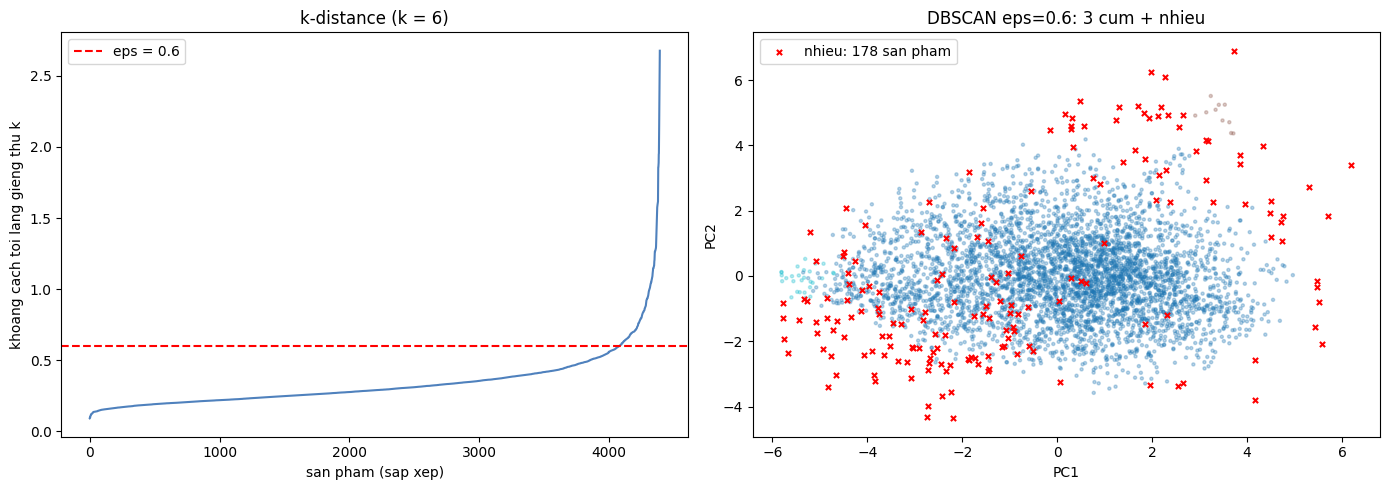

dbscan                  cum 0  cum 1  cum 2  nhieu
ten_cum                                           
Hàng chủ lực bán chạy    1037      0      0     25
Hàng giá khá bán đều     1195      0      0     11
Hàng mua sỉ theo lô       919     10      0     41
Hàng ngách khách quen     154      0     28     76
Hàng đuôi dài bán chậm    874      0      0     25


In [26]:
EPS = 0.6
db_lab = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(Z)
sp["dbscan"] = db_lab
noise = sp["dbscan"] == -1

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(kdist, color="#4f81bd")
a1.axhline(EPS, color="red", ls="--", label=f"eps = {EPS}")
a1.set(title=f"k-distance (k = {MIN_SAMPLES})", xlabel="san pham (sap xep)", ylabel="khoang cach toi lang gieng thu k")
a1.legend()
a2.scatter(Z[~noise, 0], Z[~noise, 1], s=5, alpha=0.3, c=db_lab[~noise], cmap="tab10")
a2.scatter(Z[noise, 0], Z[noise, 1], s=14, c="red", marker="x", label=f"nhieu: {noise.sum()} san pham")
a2.set(title=f"DBSCAN eps={EPS}: {db_lab.max() + 1} cum + nhieu", xlabel="PC1", ylabel="PC2")
a2.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "dbscan.png", dpi=120)
plt.show()
print(pd.crosstab(sp["ten_cum"], sp["dbscan"].map(lambda v: "nhieu" if v == -1 else f"cum {v}")))

In [27]:
cols_show = ["StockCode", "Description", "ten_cum"] + FEATURES[:4] + ["sl_moi_don", "ty_le_mua_lai"]
sp.loc[noise, cols_show].sort_values("tong_doanh_thu", ascending=False).head(12)

,StockCode,Description,ten_cum,tong_so_luong,tong_doanh_thu,gia_trung_binh,so_don_hang,sl_moi_don,ty_le_mua_lai
1550,22423,REGENCY CAKESTAND 3 TIER,Hàng chủ lực bán chạy,26478,"330,590.320",14.190,3918,6.758,2.982
3875,85123A,WHITE HANGING HEART T-LIGHT HOLDER,Hàng chủ lực bán chạy,94719,"261,168.730",3.137,5464,17.335,3.667
3854,85099B,JUMBO BAG RED RETROSPOT,Hàng chủ lực bán chạy,97176,"182,680.980",2.346,4013,24.215,4.103
2947,47566,PARTY BUNTING,Hàng chủ lực bán chạy,28200,"148,318.280",5.718,2674,10.546,2.991
3635,84879,ASSORTED COLOUR BIRD ORNAMENT,Hàng chủ lực bán chạy,80082,"129,324.490",1.859,2807,28.529,2.779
2262,23166,MEDIUM CERAMIC TOP STORAGE JAR,Hàng chủ lực bán chạy,78033,"81,700.920",1.468,247,315.923,1.790
1346,22197,SMALL POPCORN HOLDER,Hàng chủ lực bán chạy,88499,"79,520.200",1.033,2322,38.113,3.864
1068,21843,RED RETROSPOT CAKE STAND,Hàng chủ lực bán chạy,6128,"64,918.300",12.240,1527,4.013,2.549
555,21212,PACK OF 72 RETROSPOT CAKE CASES,Hàng chủ lực bán chạy,94884,"51,825.150",0.708,3118,30.431,2.796
997,21754,HOME BUILDING BLOCK WORD,Hàng chủ lực bán chạy,7595,"46,516.990",6.588,2066,3.676,3.029


**Giai thich:**
- `eps` nho (0,3) → 28 cum vun + gan 1/3 san pham bi coi la nhieu; `eps` lon (≥ 0,8) → tat ca dinh
  vao 1 cum. O khuyu do thi k-distance (eps = 0,6), DBSCAN cho **1 cum khong lo chua ~95% san pham**
  + 2 cum nho (10 ma va 28 ma) + **178 san pham nhieu**.
- Ly do: du lieu hanh vi la **mot dam may lien tuc, mat do deu**, khong co vung trong ngan cach nhom →
  DBSCAN (dua vao mat do) khong tach duoc; K-Means van "cat" duoc dam may thanh cac vung huu ich cho
  kinh doanh. Day la truong hop K-Means phu hop hon DBSCAN.
- Gia tri cua DBSCAN o day la **phat hien san pham ca biet**: 178 ma nam o vung thua (bang cheo):
  - 76 ma thuoc *khach quen* (~30% cum nay) — ty le mua lai dot bien (1 vai khach mua lai 1 ma hang chuc lan);
  - 25 ma *chu luc* nhung la cac **"ca voi" doanh thu** (REGENCY CAKESTAND, WHITE HANGING HEART...)
    hoac mua si cuc lon (MEDIUM CERAMIC TOP STORAGE JAR: 316 cai/don);
  - con lai la ma mua si dot bien / gia bat thuong.
  Nen dua danh sach nay cho bo phan mua hang xem xet rieng (ton kho, gia), khong chi dua vao nhan cum.

## 11. Xuat file ban giao

In [28]:
metrics = fit_and_export(K)
print(json.dumps(metrics, ensure_ascii=False, indent=2))
handoff = pd.read_csv(BASE_DIR / "outputs" / "san_pham_theo_cum.csv", dtype={"StockCode": str})
assert len(handoff) == len(sp) and handoff["StockCode"].is_unique
assert (handoff.set_index("StockCode")["cum"].sort_index() == sp.set_index("StockCode")["cum"].sort_index()).all()  # cung ket qua voi notebook
handoff.head(8)

{
  "so_giao_dich_sach": 1003373,
  "so_san_pham": 4395,
  "K": 5,
  "so_thanh_phan_pca": 3,
  "phuong_sai_giu_lai": 0.9064009226827484,
  "inertia": 10509.701271489448,
  "silhouette": 0.2865919397148772,
  "kich_thuoc_cum": {
    "Hàng chủ lực bán chạy": 1062,
    "Hàng giá khá bán đều": 1206,
    "Hàng ngách khách quen": 258,
    "Hàng đuôi dài bán chậm": 899,
    "Hàng mua sỉ theo lô": 970
  }
}


,StockCode,Description,cum,ten_cum,de_xuat_trung_bay,tong_doanh_thu,so_don_hang,gia_trung_binh
0,22423,REGENCY CAKESTAND 3 TIER,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","330,590.320",3918,14.190
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","261,168.730",5464,3.137
2,85099B,JUMBO BAG RED RETROSPOT,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","182,680.980",4013,2.346
3,47566,PARTY BUNTING,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","148,318.280",2674,5.718
4,84879,ASSORTED COLOUR BIRD ORNAMENT,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","129,324.490",2807,1.859
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","117,760.290",2018,3.370
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","81,700.920",247,1.468
7,79321,CHILLI LIGHTS,0,Hàng chủ lực bán chạy,"Kệ đầu dãy / lối đi chính, tầm mắt; luôn đủ tồ...","80,540.880",1135,6.291


**Giai thich:** `fit_and_export()` (trong `src/cluster.py`) chay lai dung pipeline o buoc 7 va ghi:
- `outputs/san_pham_theo_cum.csv`: `StockCode | Description | cum | ten_cum | de_xuat_trung_bay` + 3 cot tham khao
  (doanh thu, so don, gia) — sap xep theo cum, trong cum theo doanh thu giam dan.
- `outputs/mo_ta_cum.csv`: bang mo ta + de xuat trung bay.
- `models/kmeans_pipeline.joblib`: pipeline da fit, de gan cum cho san pham moi.

Hai `assert` kiem tra file ban giao trung khop 100% voi ket qua trong notebook.

## 12. Kiem tra 3 gia dinh cua K-Means

In [29]:
sizes = sp["cum"].value_counts()
spread = pd.Series({c: np.sqrt(((Z[sp["cum"] == c] - pipe["km"].cluster_centers_[c]) ** 2).sum(1)).mean()
                    for c in range(K)})
std_axes = pd.DataFrame([Z[sp["cum"] == c].std(axis=0) for c in range(K)],
                        index=[ten[c] for c in range(K)], columns=["std_PC1", "std_PC2", "std_PC3"])
std_axes["ti_le_max_min"] = std_axes.max(axis=1) / std_axes.min(axis=1)
std_axes["ban_kinh_tb"] = spread.values
std_axes["so_ma_hang"] = sizes.sort_index().values
std_axes

,std_PC1,std_PC2,std_PC3,ti_le_max_min,ban_kinh_tb,so_ma_hang
Hàng chủ lực bán chạy,0.876,0.957,0.597,1.604,1.293,1062
Hàng giá khá bán đều,0.771,0.863,0.747,1.155,1.277,1206
Hàng ngách khách quen,1.363,0.857,1.346,1.590,1.910,258
Hàng đuôi dài bán chậm,0.945,1.113,0.741,1.503,1.528,899
Hàng mua sỉ theo lô,1.066,1.053,0.584,1.827,1.435,970


**Giai thich & ket luan:**

| Gia dinh | Bai nay co thoa? |
|---|---|
| ① Cum **hinh cau**, kich thuoc tuong duong | **Thoa mot phan.** Ty le do lech chuan giua cac truc trong 1 cum 1,2–1,8 (hoi dep, chua cong/dai ro); 4 cum co ~900–1.200 ma, rieng *khach quen* chi 258 ma va ban kinh TB lon nhat (1,9 so voi 1,3–1,5) → cum thua va rong hon han. Du lieu la dam may lien tuc nen ranh gioi giua cac cum la "cat" chu khong phai khoang trong tu nhien → silhouette chi o muc chap nhan (0,29). |
| ② Moi dac trung quan trong **ngang nhau** | **Thoa sau xu ly.** Du lieu goc vi pham nang (don vi khac nhau + lech phai) → `log1p` + `StandardScaler`. Ngoai ra 4 dac trung "quy mo" trung lap → PCA de khong tinh 1 thong tin 4 lan. |
| ③ Biet truoc **K** | **Khong** — phai chon bang Elbow + Silhouette + rang buoc kinh doanh (K = 4–6) → K = 5. |

DBSCAN (buoc 10) xac nhan khong co cau truc cum "cong/dai" an trong du lieu ma K-Means bo lo: no
khong tim ra cum hinh dang khac thuong nao, chi 1 khoi lon + diem nhieu.

## 13. Mo rong

### 13.1 MiniBatchKMeans

In [30]:
rng = np.random.default_rng(RANDOM_STATE)
Z_big = np.repeat(Z, 500, axis=0) + rng.normal(0, 0.05, size=(len(Z) * 500, Z.shape[1]))  # ~2,2 trieu diem gia lap
rows = []
for name, data, n_init in [("4.395 san pham", Z, 10), (f"{len(Z_big):,} diem (x500)", Z_big, 3)]:
    for algo, est in [("KMeans", KMeans(K, n_init=n_init, random_state=RANDOM_STATE)),
                      ("MiniBatchKMeans", MiniBatchKMeans(K, n_init=n_init, batch_size=4096, random_state=RANDOM_STATE))]:
        t0 = time.time(); est.fit(data); t = time.time() - t0
        rows.append({"du_lieu": name, "thuat_toan": algo, "thoi_gian_s": t, "inertia": est.inertia_,
                     "labels": est.labels_})
mb = pd.DataFrame(rows)
for name, g in mb.groupby("du_lieu", sort=False):
    ari = adjusted_rand_score(g.iloc[0]["labels"], g.iloc[1]["labels"])
    mb.loc[g.index, "ARI_vs_KMeans"] = [1.0, ari]
    mb.loc[g.index, "inertia_tang_%"] = (g["inertia"] / g.iloc[0]["inertia"] - 1) * 100
mb = mb.drop(columns="labels")
mb.to_csv(REPORTS_DIR / "minibatch.csv", index=False)
mb

,du_lieu,thuat_toan,thoi_gian_s,inertia,ARI_vs_KMeans,inertia_tang_%
0,4.395 san pham,KMeans,0.299,"10,509.701",1.000,0.000
1,4.395 san pham,MiniBatchKMeans,0.053,"11,188.719",0.596,6.461
2,"2,197,500 diem (x500)",KMeans,5.051,"5,265,577.328",1.000,0.000
3,"2,197,500 diem (x500)",MiniBatchKMeans,0.683,"5,547,603.725",0.570,5.356


**Giai thich:** MiniBatchKMeans cap nhat tam bang tung lo nho (4.096 diem) thay vi toan bo du lieu moi vong.
- Tren 4.395 san pham: ca hai deu < 0,2 giay (tiet kiem vai phan tram giay la vo nghia) nhung MiniBatch
  **te hon ro**: inertia cao hon ~6%, ARI chi ~0,6 so voi KMeans → mat do chinh xac ma khong duoc gi.
- Tren ~2,2 trieu diem (nhan ban du lieu + nhieu): MiniBatch nhanh hon ~7 lan (≈0,7 s so voi ≈5 s), doi lai
  inertia cao hon ~5% va cach chia lech kha nhieu (ARI ~0,57).

→ Voi bai nay (vai nghin san pham) **dung KMeans thuong**; MiniBatch chi dang dung khi du lieu len hang trieu dong.

### 13.2 Hierarchical Clustering (Ward) — co cau truc phan tang?

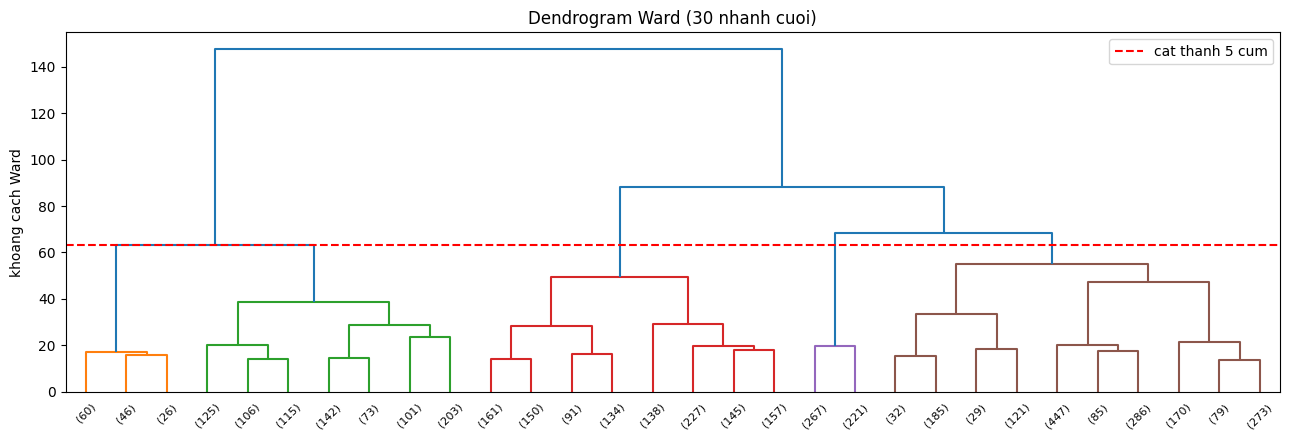

Ward 5 cum: silhouette = 0.208 | ARI voi K-Means = 0.399
cum Ward                  1    2    3    4     5
ten_cum                                         
Hàng chủ lực bán chạy     0    0    0   11  1051
Hàng giá khá bán đều      0   62  334  477   333
Hàng mua sỉ theo lô       0    0  648    0   322
Hàng ngách khách quen   132   60   65    0     1
Hàng đuôi dài bán chậm    0  743  156    0     0


In [31]:
Lw = linkage(Z, method="ward")
hc5 = fcluster(Lw, t=K, criterion="maxclust")
fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Lw, truncate_mode="lastp", p=30, ax=ax, color_threshold=Lw[-(K - 1), 2], leaf_font_size=8)
ax.axhline(Lw[-(K - 1), 2], color="red", ls="--", label=f"cat thanh {K} cum")
ax.set(title="Dendrogram Ward (30 nhanh cuoi)", ylabel="khoang cach Ward")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "dendrogram.png", dpi=120)
plt.show()
print(f"Ward 5 cum: silhouette = {silhouette_score(Z, hc5):.3f} | ARI voi K-Means = {adjusted_rand_score(sp['cum'], hc5):.3f}")
print(pd.crosstab(sp["ten_cum"], hc5, colnames=["cum Ward"]))

**Giai thich:** Ward gop dan cac nhom sao cho inertia tang it nhat — cung muc tieu voi K-Means nhung
tham lam tu duoi len, gop roi khong tach lai.
- **Co cau truc phan tang:** buoc gop cuoi cung xa vuot troi (khoang cach ~147 so voi ~88 cua buoc truoc).
  Cat o 2 cum, Ward tach {*duoi dai ban cham* + phan lon *khach quen*} khoi {*chu luc*, *mua si*, *ban deu*}
  → tang tren cung la **"ban cham ↔ ban chay"**, sau do moi tach theo **kieu mua** (si/le, gia).
- Cat o 5 cum, Ward chi **khop mot phan** voi K-Means (ARI 0,40, silhouette 0,21 < 0,29): *chu luc* va
  *duoi dai* trung khop tot, nhung *gia kha ban deu* bi Ward chia ra 3 nhom. Ward khong sua duoc cac lan
  gop sai som, nen cho cach chia kem gon hon K-Means tren du lieu nay.

### 13.3 Kiem cheo voi Market Basket — san pham cung cum co hay duoc mua chung?

Khong can cai `mlxtend`: tinh truc tiep **lift** cho moi cap san pham tu ma tran hoa don × san pham:
$\text{lift}(a,b) = \dfrac{P(a,b)}{P(a)\,P(b)}$ — lift > 1 nghia la mua chung nhieu hon ngau nhien.

In [32]:
from scipy import sparse
tx_sp = tx[tx["StockCode"].isin(sp["StockCode"])][["Invoice", "StockCode"]].drop_duplicates()
inv_idx = tx_sp["Invoice"].astype("category").cat.codes.values
code_cat = pd.Categorical(tx_sp["StockCode"], categories=sp["StockCode"])
B = sparse.csr_matrix((np.ones(len(tx_sp), dtype=np.float32), (inv_idx, code_cat.codes)))
n_inv = B.shape[0]
co = (B.T @ B).toarray()                      # so hoa don co ca a va b
cnt = np.diag(co).copy()
iu = np.triu_indices_from(co, k=1)
pair_cnt = co[iu]
keep = pair_cnt >= 30                         # cap du du lieu (>= 30 hoa don chung)
a, b, c_ab = iu[0][keep], iu[1][keep], pair_cnt[keep]
lift = c_ab * n_inv / (cnt[a] * cnt[b])
same = sp["cum"].values[a] == sp["cum"].values[b]
p = sp["cum"].value_counts(normalize=True)
baseline = (p ** 2).sum()

# Doi chung "cung do pho bien": xao tron nhan cum TRONG tung nhom thap phan vi so hoa don cua san pham
# → giu nguyen moi lien he "pho bien <-> cum" nhung pha vo moi thong tin khac.
pop_dec = pd.qcut(np.log(cnt), 10, labels=False)
bins = [(0, 1, "lift < 1 (it mua chung)"), (1, 3, "1 ≤ lift < 3"), (3, 10, "3 ≤ lift < 10"),
        (10, np.inf, "lift ≥ 10 (rat hay mua chung)")]
lab_arr = sp["cum"].values
null = []
for _ in range(20):
    lab_perm = lab_arr.copy()
    for d in range(10):
        idx = np.where(pop_dec == d)[0]
        lab_perm[idx] = rng.permutation(lab_arr[idx])
    same_p = lab_perm[a] == lab_perm[b]
    null.append([same_p[(lift >= lo) & (lift < hi)].mean() for lo, hi, _ in bins])
null = np.mean(null, axis=0)

rows = [("Moi cap (ngau nhien hoan toan)", np.nan, baseline, np.nan)]
for (lo, hi, lbl), nl in zip(bins, null):
    m = (lift >= lo) & (lift < hi)
    rows.append((lbl, int(m.sum()), same[m].mean(), nl))
order_lift = np.argsort(-lift)
for N in [100, 1000]:
    rows.append((f"Top {N} cap lift cao nhat", N, same[order_lift[:N]].mean(), np.nan))
basket = pd.DataFrame(rows, columns=["nhom_cap", "so_cap", "ty_le_cung_cum", "doi_chung_cung_do_pho_bien"])
basket.to_csv(REPORTS_DIR / "mua_chung_vs_cum.csv", index=False)
print(f"{n_inv:,} hoa don, {keep.sum():,} cap co >= 30 hoa don chung")
basket

39,498 hoa don, 332,820 cap co >= 30 hoa don chung


,nhom_cap,so_cap,ty_le_cung_cum,doi_chung_cung_do_pho_bien
0,Moi cap (ngau nhien hoan toan),NaN,0.228,NaN
1,lift < 1 (it mua chung),236.000,0.949,0.883
2,1 ≤ lift < 3,"81,301.000",0.807,0.797
3,3 ≤ lift < 10,"194,878.000",0.666,0.623
4,lift ≥ 10 (rat hay mua chung),"56,405.000",0.418,0.388
5,Top 100 cap lift cao nhat,100.000,0.790,NaN
6,Top 1000 cap lift cao nhat,"1,000.000",0.744,NaN


In [33]:
top = np.argsort(-lift)[:10]
pd.DataFrame({"san_pham_a": sp["Description"].values[a[top]], "san_pham_b": sp["Description"].values[b[top]],
              "so_hd_chung": c_ab[top].astype(int), "lift": lift[top].round(1),
              "cum_a": sp["ten_cum"].values[a[top]], "cum_b": sp["ten_cum"].values[b[top]]})

,san_pham_a,san_pham_b,so_hd_chung,lift,cum_a,cum_b
0,PINK KNITTED EGG COSY,BLUE KNITTED EGG COSY,36,752.300,Hàng đuôi dài bán chậm,Hàng đuôi dài bán chậm
1,SET/6 WOODLAND PAPER CUPS,SET/6 WOODLAND PAPER PLATES,42,534.800,Hàng mua sỉ theo lô,Hàng mua sỉ theo lô
2,MIRRORED WALL ART GENTS,MIRRORED WALL ART LADIES,38,532.200,Hàng đuôi dài bán chậm,Hàng đuôi dài bán chậm
3,LANDMARK FRAME OXFORD STREET,LANDMARK FRAME COVENT GARDEN,40,523.000,Hàng giá khá bán đều,Hàng giá khá bán đều
4,LANDMARK FRAME NOTTING HILL,LANDMARK FRAME COVENT GARDEN,31,462.100,Hàng giá khá bán đều,Hàng giá khá bán đều
5,LANDMARK FRAME OXFORD STREET,LANDMARK FRAME NOTTING HILL,30,415.800,Hàng giá khá bán đều,Hàng giá khá bán đều
6,STRAWBRY SCENTED VOTIVE CANDLE,ORANGE VOTIVE CANDLE,30,390.300,Hàng mua sỉ theo lô,Hàng mua sỉ theo lô
7,EGG CUP MILKMAID HELGA,EGG CUP MILKMAID HEIDI,48,362.600,Hàng giá khá bán đều,Hàng mua sỉ theo lô
8,EGG CUP MILKMAID INGRID,EGG CUP MILKMAID HEIDI,56,350.600,Hàng mua sỉ theo lô,Hàng mua sỉ theo lô
9,BLUE KNITTED HEN,PEACH KNITTED HEN,47,337.900,Hàng mua sỉ theo lô,Hàng mua sỉ theo lô


**Giai thich — ket qua NGUOC voi ky vong ban dau, can doc can than:**

1. Nhin tho: moi nhom cap mua chung deu co ty le cung cum (0,42–0,95) **cao hon nhieu** muc ngau nhien
   $\sum_c p_c^2 \approx 0{,}23$. Nhung ty le nay lai **GIAM** khi lift tang — nguoc voi gia thuyet
   "cang hay mua chung cang cung cum".
2. Ly do: chi xet cap co ≥ 30 hoa don chung → loc ra chu yeu san pham **pho bien**; ma do pho bien chinh
   la truc PC1 quyet dinh cum (*chu luc*). Hai san pham ban chay vua hay xuat hien chung (lift thap vi
   P(a), P(b) da lon) vua cung cum *chu luc* → ty le cung cum cao la do **pho bien**, khong phai do mua chung.
3. Cot `doi_chung_cung_do_pho_bien` xao tron nhan cum giua cac san pham co cung muc pho bien: ty le cung cum
   chi thap hon thuc te **0,01–0,07** → sau khi tru hieu ung pho bien, cum hanh vi **gan nhu khong mang
   them thong tin "mua chung"**.
4. Ngoai le: top 100 cap lift cao nhat ~80% cung cum — do la cac **bien the cung 1 mau** (khac mau/khac ten:
   LANDMARK FRAME OXFORD STREET / COVENT GARDEN, EGG CUP MILKMAID INGRID / HEIDI) nen cung gia, cung tan suat.

**Ket luan kiem cheo:** cum K-Means tra loi cau hoi *"san pham ban the nao"* (nhanh/cham, si/le) — dung de
chon **khu** trung bay. Cau hoi *"dat san pham nao canh nhau"* can mot phan tich rieng (luat ket hop/Apriori);
hai phan tich bo sung cho nhau chu khong thay the nhau.

## 14. Tom tat

In [34]:
best_by_k = k_tbl.loc[4:6, "silhouette_PCA"]
tom_tat = {
    "lam_sach": clean_log.set_index("buoc")["so_dong_bi_loai"].astype(int).to_dict(),
    "san_pham_loai_vi_duoi_5_don": int(len(sp_all) - len(sp)),
    "so_san_pham": int(len(sp)),
    "skew_truoc_sau_log": skew_df.round(2).to_dict(orient="index"),
    "pca_so_thanh_phan": int(pipe["pca"].n_components_),
    "pca_phuong_sai": round(float(pipe["pca"].explained_variance_ratio_.sum()), 3),
    "silhouette_K_4_5_6_PCA": best_by_k.round(3).to_dict(),
    "silhouette_K_4_5_6_8D": k_tbl.loc[4:6, "silhouette_8D"].round(3).to_dict(),
    "K_chon": K,
    "silhouette_cuoi": round(float(sil_final), 3),
    "n_init": summary.reset_index().round(3).to_dict(orient="records"),
    "dbscan": {"eps": EPS, "min_samples": MIN_SAMPLES, "so_cum": int(db_lab.max() + 1), "so_nhieu": int(noise.sum())},
    "cum": names_tbl[["ten_cum", "so_ma_hang", "pct_doanh_thu"]].to_dict(orient="records"),
    "ward_ARI_vs_kmeans": round(float(adjusted_rand_score(sp["cum"], hc5)), 3),
    "mua_chung": basket.round(3).to_dict(orient="records"),
}
(REPORTS_DIR / "tom_tat.json").write_text(json.dumps(tom_tat, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
print(json.dumps(tom_tat, ensure_ascii=False, indent=2, default=float))

{
  "lam_sach": {
    "Ban dau": 0,
    "1. Loai hoa don huy (Invoice bat dau 'C')": 19494,
    "2. Loai Quantity <= 0 va Price <= 0": 6207,
    "3. Loai StockCode khong phai san pham": 4633,
    "   Loai dong trung lap hoan toan": 33664
  },
  "san_pham_loai_vi_duoi_5_don": 334,
  "so_san_pham": 4395,
  "skew_truoc_sau_log": {
    "tong_so_luong": {
      "skew_goc": 7.91,
      "skew_sau_log1p": -0.25
    },
    "tong_doanh_thu": {
      "skew_goc": 11.83,
      "skew_sau_log1p": -0.17
    },
    "gia_trung_binh": {
      "skew_goc": 14.23,
      "skew_sau_log1p": 0.94
    },
    "so_don_hang": {
      "skew_goc": 4.08,
      "skew_sau_log1p": -0.06
    },
    "so_khach_mua": {
      "skew_goc": 2.59,
      "skew_sau_log1p": -0.34
    },
    "do_lech_sl": {
      "skew_goc": 18.27,
      "skew_sau_log1p": 0.57
    },
    "sl_moi_don": {
      "skew_goc": 33.99,
      "skew_sau_log1p": 1.07
    },
    "ty_le_mua_lai": {
      "skew_goc": 9.35,
      "skew_sau_log1p": 2.5
    }
  },
  